# Variable-cell relaxation

`calculation = 'vc-relax'` relaxes the **cell** as well as the atoms. What is minimised is
the enthalpy $H = E + P\Omega$, so the stationary point is $\sigma = P\,\mathbf 1$: a
relaxed crystal carries the applied pressure rather than having no stress. The cell is nine
more coordinates of the same optimisation, and its gradient is the stress rearranged,

$$\frac{\partial H}{\partial h} = \Omega\,(P\,\mathbf 1 - \sigma)\,h^{-T},$$

where $h$ is the matrix whose columns are the lattice vectors.

The case below is QE's own `vc-relax4.in`: rhombohedral arsenic squeezed at **500 kbar**,
where the cell compresses by 10% *and* the two atoms move from 0.2722 to 0.2500, which is
the rhombohedral to simple-cubic transition. Against `pw.x` the relaxed volume agrees to
**2.6e-5 bohr³**, the atoms to **5.7e-6** in crystal coordinates and the final energy to
**1.0e-7 Ry**, in the same ten ionic steps -- `pw.x` reports that as "10 scf cycles
and 9 bfgs steps", the two counts differing by the step it accepts without re-solving.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import read_qe_output
from pypresso.units import RY_TO_KBAR

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")
QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_vc-relax")

arsenic = Calculator.from_file(QE / "vc-relax4.in", pseudo_dir=PSEUDO, announce=False)
print("%d atoms, applied pressure %g kbar, starting volume %.2f bohr^3"
      % (arsenic.system.structure.nat, arsenic.system.relax.press,
         float(arsenic.system.cell.volume)))

2 atoms, applied pressure 500 kbar, starting volume 245.37 bohr^3


## Run it

Everything the run needs is in the input: the pressure, its convergence threshold and which
degrees of freedom of the cell are free. All three thresholds, energy, force **and**
pressure, have to be satisfied together.

In [2]:
result = arsenic.get_relax(variable_cell=True)

print(f"converged in {result.nsteps} ionic steps")
print(f"volume   {result.steps[0].volume:8.2f}  ->  {result.volume:8.2f} bohr^3")
print(f"energy   {result.total_energy:.8f} Ry")
print(f"enthalpy {result.enthalpy:.8f} Ry")
print(f"pressure {np.trace(result.stress) / 3 * RY_TO_KBAR:.2f} kbar "
      f"(asked for {arsenic.system.relax.press})")

converged in 10 ionic steps
volume     245.37  ->    190.79 bohr^3
energy   -25.39781852 Ry
enthalpy -24.74934425 Ry
pressure 501.84 kbar (asked for 500.0)


## Against `pw.x`

What is compared is the relaxed geometry and the energy of the **final SCF**, the extra run
done at the relaxed cell with its plane-wave basis rebuilt for it. The relaxation itself
runs in a basis chosen for the *starting* cell, so its own last energy is not variational in
the cell it is reported at. The gap between the two is the Pulay error of a fixed basis
under a changing volume, and it is the number to read before believing a relaxed volume
computed at a low cutoff.

In [3]:
reference = read_qe_output(CASES / "reference.out.pw_vc-relax-vc-relax4")
qe_crystal = reference.final_positions @ np.linalg.inv(reference.final_cell)

rows = [
    ("volume (bohr^3)", result.volume, abs(np.linalg.det(reference.final_cell))),
    ("a1 . x (bohr)", result.cell[0, 0], reference.final_cell[0, 0]),
    ("a1 . z (bohr)", result.cell[0, 2], reference.final_cell[0, 2]),
    ("As at (crystal)", result.positions_crystal[0, 0], qe_crystal[0, 0]),
    # ``final_total_energy``: the *last* "!  total energy" in the file, which is
    # the final SCF's. ``total_energy`` is the first -- the starting geometry's.
    ("total energy (Ry)", result.total_energy, reference.final_total_energy),
]
print(f"{'':20s} {'pypresso':>14s} {'pw.x':>14s} {'difference':>12s}")
for label, ours, theirs in rows:
    print(f"{label:20s} {ours:14.6f} {theirs:14.6f} {abs(ours - theirs):12.2e}")
print(f"\nPulay error of the frozen basis: {result.pulay_error:.2e} Ry")

                           pypresso           pw.x   difference
volume (bohr^3)          190.787717     190.787743     2.64e-05
a1 . x (bohr)              3.744158       3.744159     1.40e-06
a1 . z (bohr)              5.238299       5.238296     3.19e-06
As at (crystal)            0.249998       0.250004     5.69e-06
total energy (Ry)        -25.397819     -25.397819     1.03e-07

Pulay error of the frozen basis: 3.67e-03 Ry


## The physics: the cell and the atoms are doing different things

Arsenic's rhombohedral structure is a distorted simple cubic one: the two atoms sit at
$\pm u(1,1,1)$ with $u = 0.2722$ instead of the $0.25$ that would make every bond equal.
Pressure removes the distortion, and the plot is that transition happening. The volume falls
and $u$ climbs to a quarter, and neither is imposed. This is the structural phase transition
of arsenic under pressure, obtained from nothing but the enthalpy and its gradient.

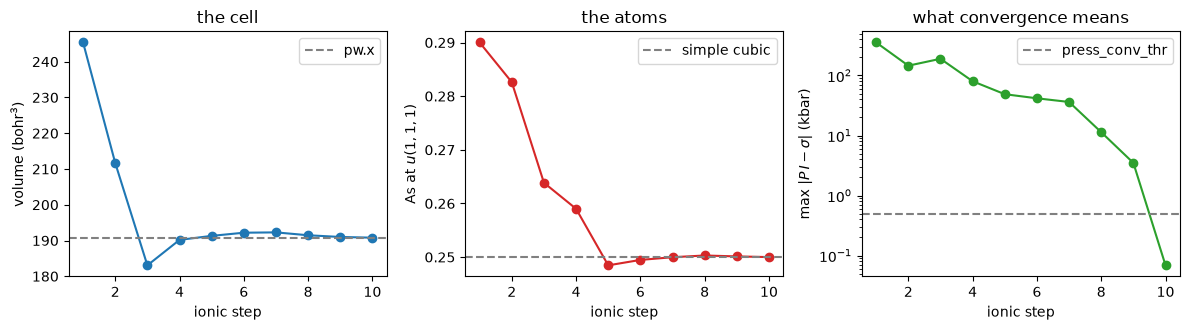

In [4]:
steps = result.steps
volume = [s.volume for s in steps]
u = [s.positions[0] @ np.linalg.inv(s.cell) for s in steps]
u = [x[0] for x in u]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

axes[0].plot(range(1, len(steps) + 1), volume, "o-", color="#1f77b4")
axes[0].axhline(abs(np.linalg.det(reference.final_cell)), ls="--", color="grey",
                label="pw.x")
axes[0].set_xlabel("ionic step"); axes[0].set_ylabel("volume (bohr$^3$)")
axes[0].set_title("the cell"); axes[0].legend()

axes[1].plot(range(1, len(steps) + 1), u, "o-", color="#d62728")
axes[1].axhline(0.25, ls="--", color="grey", label="simple cubic")
axes[1].set_xlabel("ionic step"); axes[1].set_ylabel("As at $u(1,1,1)$")
axes[1].set_title("the atoms"); axes[1].legend()

axes[2].plot(range(1, len(steps) + 1),
             [s.cell_error * RY_TO_KBAR for s in steps], "o-", color="#2ca02c")
axes[2].axhline(arsenic.system.relax.press_conv_thr, ls="--", color="grey",
                label="press_conv_thr")
axes[2].set_yscale("log")
axes[2].set_xlabel("ionic step"); axes[2].set_ylabel(r"max $|P\,I - \sigma|$ (kbar)")
axes[2].set_title("what convergence means"); axes[2].legend()

fig.tight_layout()

## Where the cell gradient comes from

A deformation $h \to (1 + \epsilon)h$ gives $\epsilon = dh\,h^{-1}$, so
$dE/dh = (dE/d\epsilon)\,h^{-T}$; with $\sigma = -(1/\Omega)\,dE/d\epsilon$ and
$d\Omega/dh = \Omega h^{-T}$, the enthalpy's gradient is the expression in the header.
Contracting it back with $h^{T}$ returns $P\,\mathbf 1 - \sigma$, which is why the cell's
convergence is reported in kbar: what has to go to zero is a pressure difference.

In [5]:
from pypresso.relax.cell import cell_force   # no facade route to dH/dh

h = result.cell.T                      # QE's convention: lattice vectors as columns
omega = result.volume
pressure = arsenic.system.relax.press / RY_TO_KBAR

gradient = cell_force(result.stress, h, omega, pressure)
recovered = gradient @ h.T / omega     # ... must be P I - sigma again

print("dH/dh at the relaxed cell (Ry/bohr):")
print(np.array2string(gradient, precision=6, suppress_small=True))
print("\ncontracted back, max |P I - sigma| =",
      f"{np.abs(recovered).max() * RY_TO_KBAR:.3f} kbar")

dH/dh at the relaxed cell (Ry/bohr):
[[-0.000397  0.000198  0.000198]
 [-0.       -0.000344  0.000344]
 [-0.000171 -0.000171 -0.000171]]

contracted back, max |P I - sigma| = 2.071 kbar


## What a moving cell does to the k-points

A k-point is fixed in **crystal** coordinates, not in cartesian ones: deforming the cell
carries the reciprocal lattice with it, and the same physical k-point acquires different
cartesian components. That is invisible in a calculation whose cell has not moved, and it is
the first thing a variable-cell relaxation reaches. Getting it wrong leaves the energy right
and its derivative wrong, here by 64 kbar and by 2% of the relaxed volume. The check is a
finite difference of the frozen-basis energy, below.

In [6]:
print(f"{'crystal k-point':>28s}   {'from the run':>22s}")
base = np.asarray(arsenic.system.kpoints.crystal(arsenic.system.cell))
final = np.asarray(result.system.kpoints.crystal(result.system.cell))
for a, b in list(zip(base, final))[:3]:
    print(f"{np.array2string(a, precision=5):>28s}   {np.array2string(b, precision=5):>22s}")
print(f"\nmax difference after the cell moved: {np.abs(base - final).max():.2e}")

             crystal k-point             from the run
         [0.125 0.125 0.125]      [0.125 0.125 0.125]
         [0.125 0.125 0.375]      [0.125 0.125 0.375]
      [ 0.125  0.125 -0.375]   [ 0.125  0.125 -0.375]

max difference after the cell moved: 1.11e-16


---
The tests behind this notebook: `tests/regression/test_vc_relax.py`, which carries QE's
three comparable cases plus an eight-atom cubic silicon supercell under pressure and the
ten-atom graphite whose `c` and `a` have to move independently.